# EDA

## Data Loading

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
with open('../data/TXB_23_landingpage(in).csv', 'rb') as f:
    raw = f.read()

lines = raw.split(b'\r\n')
cleaned = []
for line in lines:
    line = line.strip()
    if line.startswith(b'"') and line.endswith(b'"'):
        line = line[1:-1]
    line = line.replace(b'""', b'"')
    cleaned.append(line.decode('utf-8', errors='replace'))

from io import StringIO
df = pd.read_csv(StringIO('\n'.join(cleaned)))

In [19]:
print(df.shape)
df.head()

(1163, 16)


,group_id,arm,visitor_id,arrival_time,exit_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,kpi_x,kpi_y,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
0,TXB_23,treatment,355,2026-02-22 11:54:51,2026-02-22 11:55:01.9,10.9,0,0,1,0,0,13.14,0,86.4,0,2654.2
1,TXB_23,treatment,389,2026-02-22 22:03:14,2026-02-22 22:07:29.4,255.4,0,0,0,0,0,6.65,0,36.4,0,1451.9
2,TXB_23,treatment,781,2026-02-22 22:07:43,2026-02-22 23:04:55.6,3432.6,0,0,1,1,1,24.55,0,89.9,0,2517.1
3,TXB_23,pre,190,2026-02-22 22:22:10,2026-02-22 22:22:52,42.0,0,0,0,0,0,37.45,0,90.1,0,1192.1
4,TXB_23,pre,1,2026-02-22 23:31:43.201452,2026-02-22 23:33:13.78465,90.6,0,0,0,0,0,16.20,0,17.9,0,1966.6


## Missing Values Analysis


We have no missing values in our dataset

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1163 entries, 0 to 1162
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   group_id            1163 non-null   object 
 1   arm                 1163 non-null   object 
 2   visitor_id          1163 non-null   int64  
 3   arrival_time        1163 non-null   object 
 4   exit_time           1163 non-null   object 
 5   time_on_page_sec    1163 non-null   float64
 6   exit_rate           1163 non-null   int64  
 7   ctr_opportunities   1163 non-null   int64  
 8   ctr_newsletter      1163 non-null   int64  
 9   ctr_donation        1163 non-null   int64  
 10  ctr_events          1163 non-null   int64  
 11  kpi_x               1163 non-null   float64
 12  kpi_y               1163 non-null   int64  
 13  scroll_depth_pct    1163 non-null   float64
 14  ctr_partner_banner  1163 non-null   int64  
 15  page_load_time_ms   1163 non-null   float64
dtypes: flo

## Data Types & Formatting

The `arrival_time` and `exit_time` columns were loaded as strings and need to be converted 
to datetime format for temporal analysis. Some timestamps have mixed precision 
(some with microseconds, some without), so we use `format='mixed'` to handle this.

In [21]:
df['arrival_time'] = pd.to_datetime(df['arrival_time'], format='mixed')
df['exit_time'] = pd.to_datetime(df['exit_time'], format='mixed')

print(df[['arrival_time', 'exit_time']].dtypes)

arrival_time    datetime64[ns]
exit_time       datetime64[ns]
dtype: object


## Univariate Analysis

We analyze the distribution of each key metric individually to understand 
the overall behavior of visitors, before splitting by arm.
We focus on the continuous variables: `time_on_page_sec`, `scroll_depth_pct`, 
`page_load_time_ms`, and `kpi_x`, and the binary variables: `exit_rate`, 
`ctr_newsletter`, `ctr_donation`, `ctr_events`, `kpi_y`, `ctr_partner_banner`.

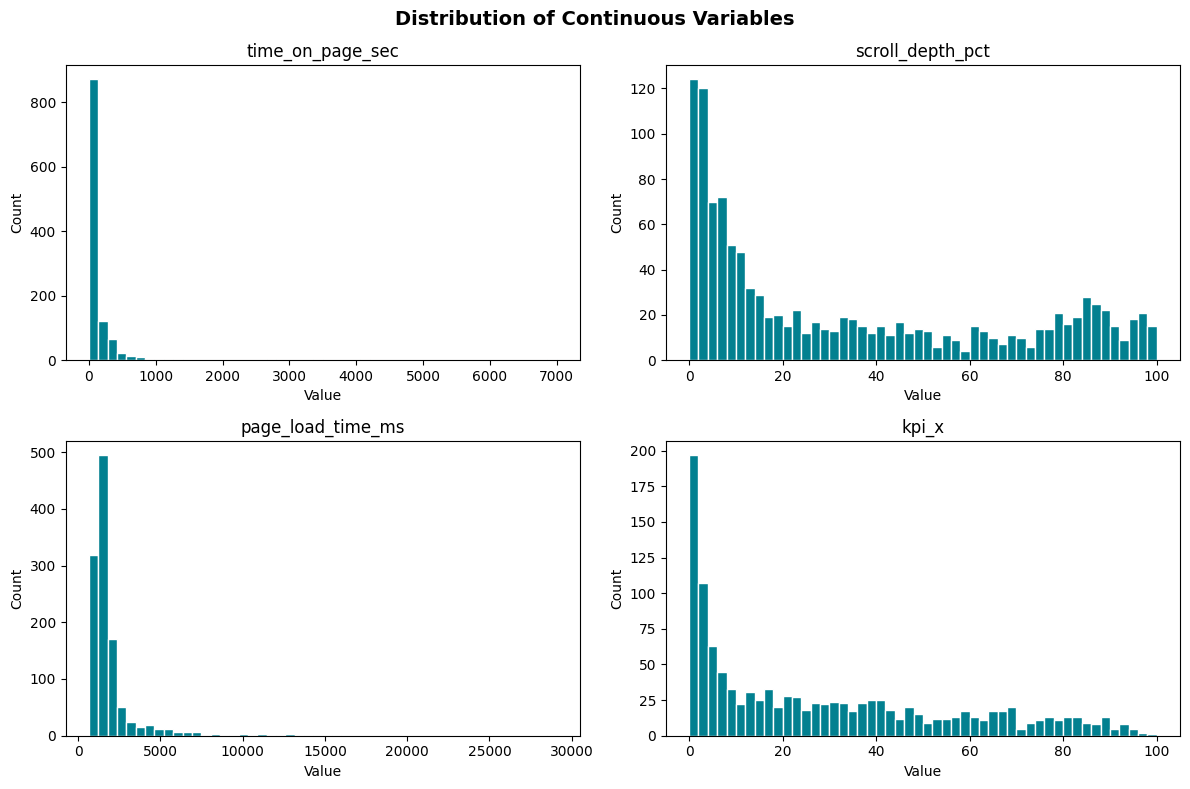

In [22]:
continuous = ['time_on_page_sec', 'scroll_depth_pct', 'page_load_time_ms', 'kpi_x']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous):
    axes[i].hist(df[col], bins=50, color='#028090', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Continuous Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/univariate_continuous.png', dpi=150)
plt.show()

### Binary Variables
The following metrics are binary (0/1) flags per visitor session.

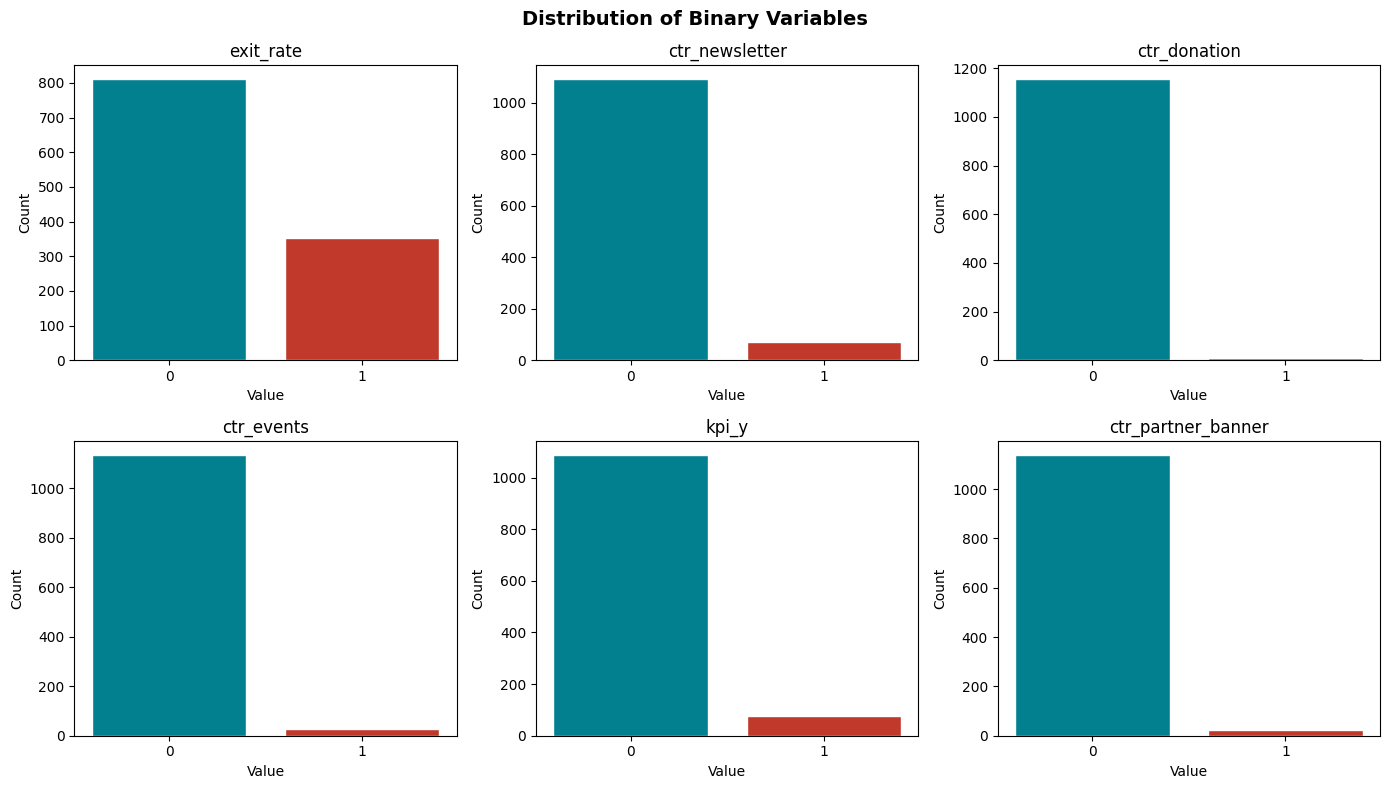

In [23]:
binary = ['exit_rate', 'ctr_newsletter', 'ctr_donation', 'ctr_events', 'kpi_y', 'ctr_partner_banner']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(binary):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=['#028090', '#C0392B'], edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Binary Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/univariate_binary.png', dpi=150)
plt.show()

## Bivariate Analysis — Pre vs Treatment

We now compare each metric between the two arms to identify 
any differences in behavior before and after the CTA change.

### Continuous Variables by Arm

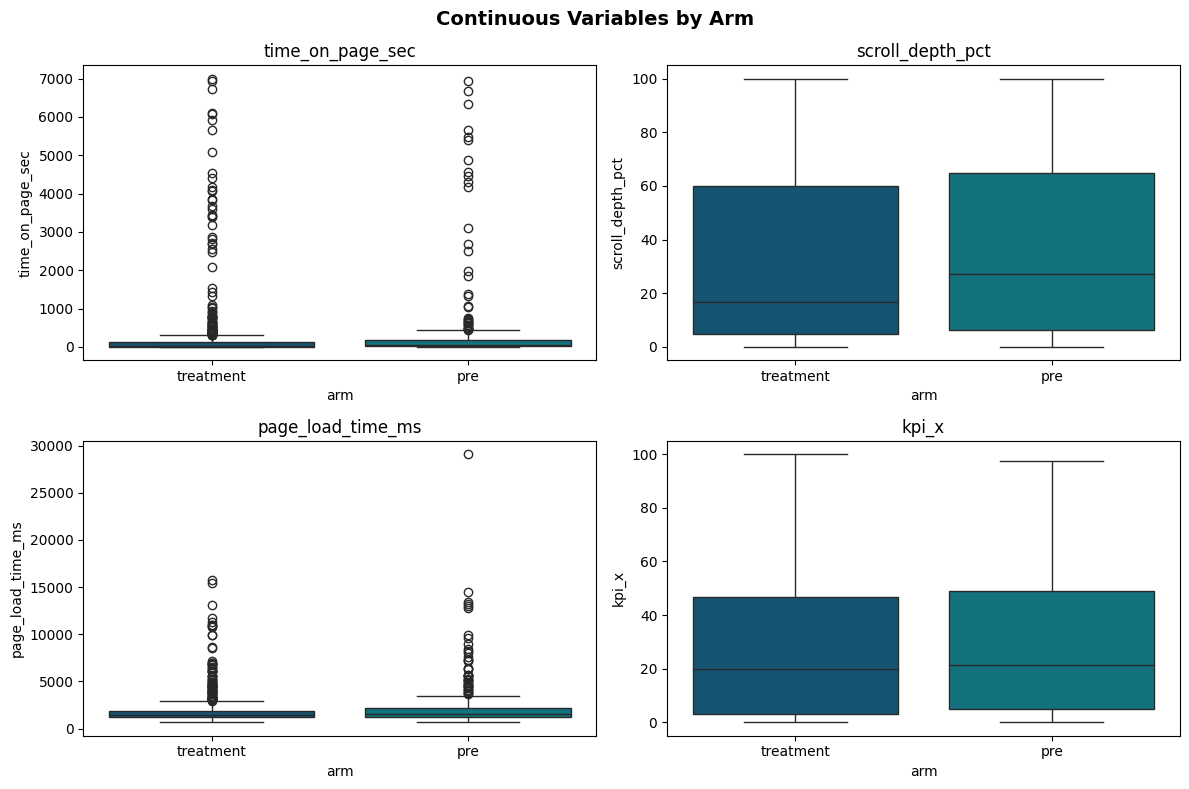

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous):
    sns.boxplot(data=df, x='arm', y=col, ax=axes[i], hue='arm', palette={'pre': '#028090', 'treatment': '#065A82'}, legend=False)
    axes[i].set_title(col)

plt.suptitle('Continuous Variables by Arm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/bivariate_continuous.png', dpi=150)
plt.show()

### Binary Variables by Arm
We compare the proportion of visitors who triggered each binary metric 
across the two arms.

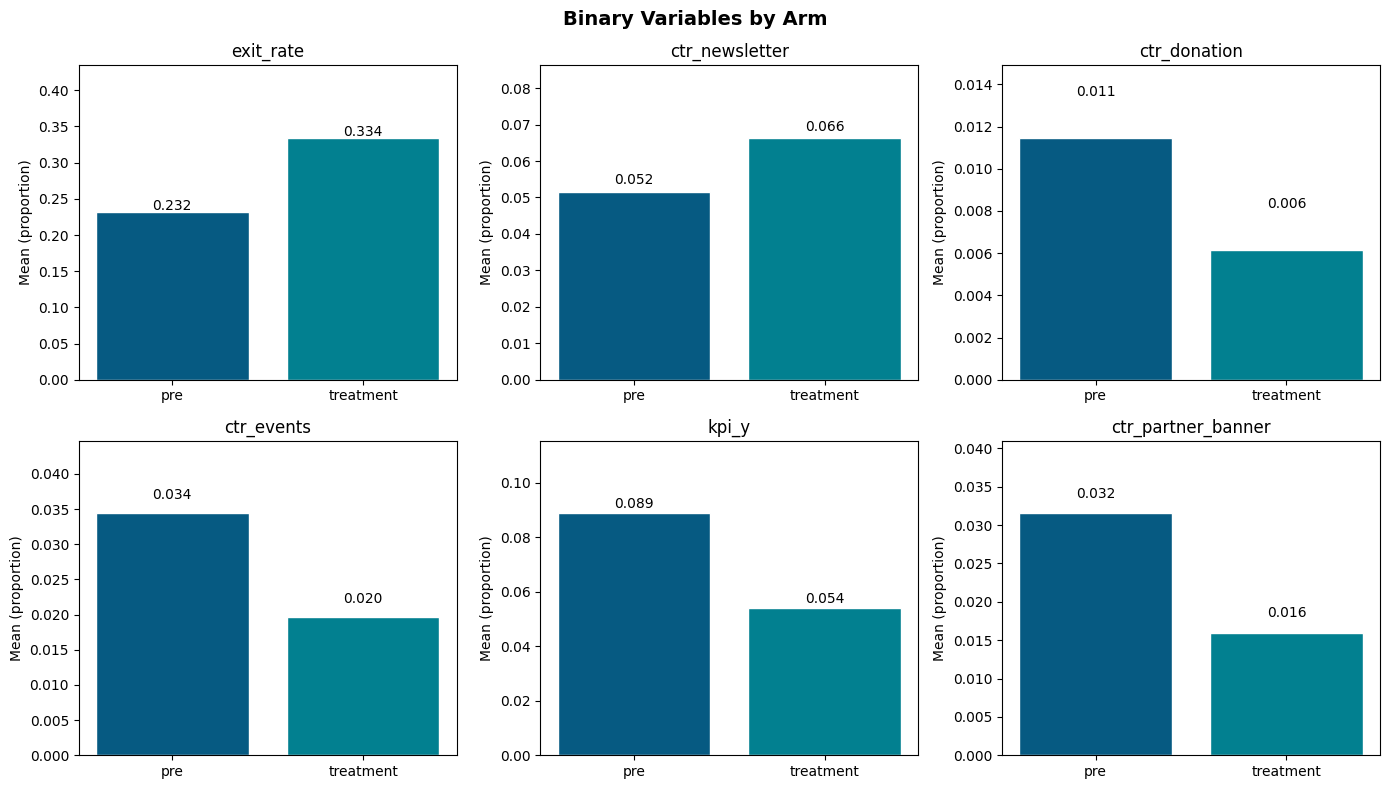

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(binary):
    ct = df.groupby('arm')[col].mean().reset_index()
    axes[i].bar(ct['arm'], ct[col], color=['#065A82', '#028090'], edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Mean (proportion)')
    axes[i].set_ylim(0, ct[col].max() * 1.3)
    for j, row in ct.iterrows():
        axes[i].text(j, row[col] + 0.002, f"{row[col]:.3f}", ha='center')

plt.suptitle('Binary Variables by Arm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/bivariate_binary.png', dpi=150)
plt.show()



- **exit_rate** — jumped from 0.232 to 0.334, meaning **more people left** after the CTA change 
- **ctr_newsletter** — slight increase (0.052 → 0.066), small positive 
- **ctr_donation** — dropped by almost half (0.011 → 0.006) 
- **ctr_events** — dropped (0.034 → 0.020) 
- **kpi_y** — dropped significantly (0.089 → 0.054) 
- **ctr_partner_banner** — dropped by half (0.032 → 0.016) 

Almost everything went **down** in the treatment arm except newsletter CTR. 
This is a strong early signal that the new CTA button may not have had the intended effect.

## Outlier Detection

We use the IQR method to identify outliers in the continuous variables.
A value is considered an outlier if it falls below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

In [26]:
for col in continuous:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

time_on_page_sec: 129 outliers (11.1%)
scroll_depth_pct: 0 outliers (0.0%)
page_load_time_ms: 123 outliers (10.6%)
kpi_x: 0 outliers (0.0%)


### Outlier Treatment

`time_on_page_sec` and `page_load_time_ms` both have ~11% outliers.
For `time_on_page_sec`, extreme values likely represent users who left the tab open.
For `page_load_time_ms`, extreme values likely represent poor network conditions.

Since these outliers are present in **both arms**, they should not bias the comparison.
We will keep them in the dataset but cap them at the 99th percentile (winsorization)
to reduce their influence on the statistical analysis.

In [27]:
for col in ['time_on_page_sec', 'page_load_time_ms']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)
    print(f"{col} capped at {cap:.1f}")

time_on_page_sec capped at 5421.8
page_load_time_ms capped at 10993.7


## Temporal Analysis

We analyze visitor traffic over time to check for any unusual spikes or drops 
during the test period, and to confirm the arms are clearly separated in time.

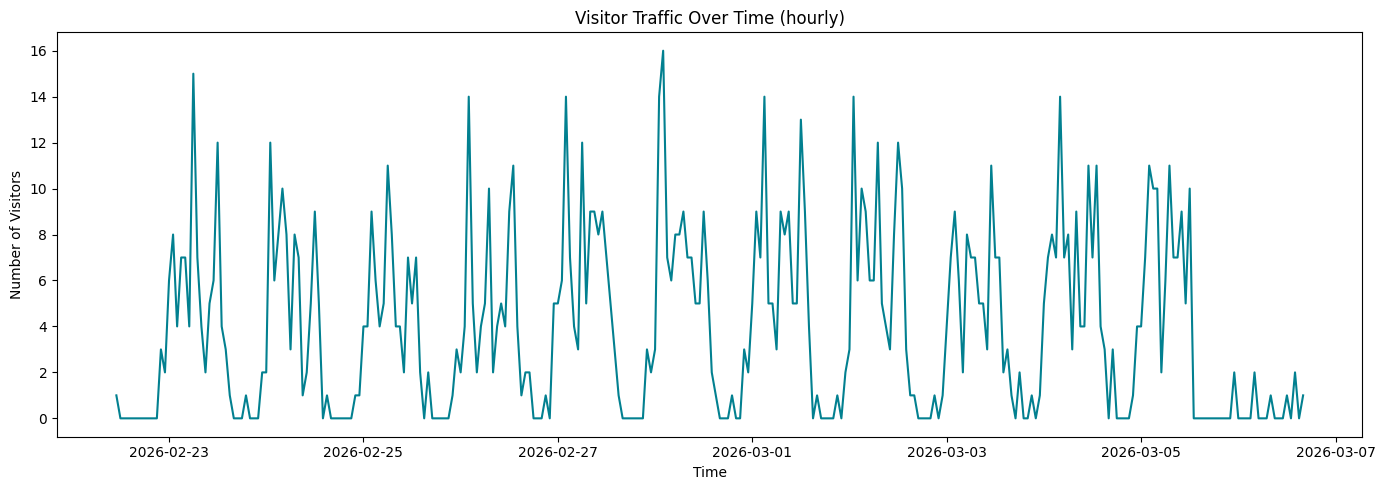

In [28]:
df_time = df.set_index('arrival_time').resample('h').size().reset_index()
df_time.columns = ['hour', 'visitors']

plt.figure(figsize=(14, 5))
plt.plot(df_time['hour'], df_time['visitors'], color='#028090', linewidth=1.5)
plt.title('Visitor Traffic Over Time (hourly)')
plt.xlabel('Time')
plt.ylabel('Number of Visitors')
plt.tight_layout()
plt.savefig('../outputs/figures/temporal_traffic.png', dpi=150)
plt.show()

In [29]:
print("Pre arm:")
print(df[df['arm'] == 'pre']['arrival_time'].min())
print(df[df['arm'] == 'pre']['arrival_time'].max())

print("\nTreatment arm:")
print(df[df['arm'] == 'treatment']['arrival_time'].min())
print(df[df['arm'] == 'treatment']['arrival_time'].max())

Pre arm:
2026-02-22 22:22:10
2026-03-06 14:47:46

Treatment arm:
2026-02-22 11:54:51
2026-03-06 16:22:26


## Correlation Analysis

We analyze how the numeric metrics relate to each other to identify 
any patterns or dependencies between variables.

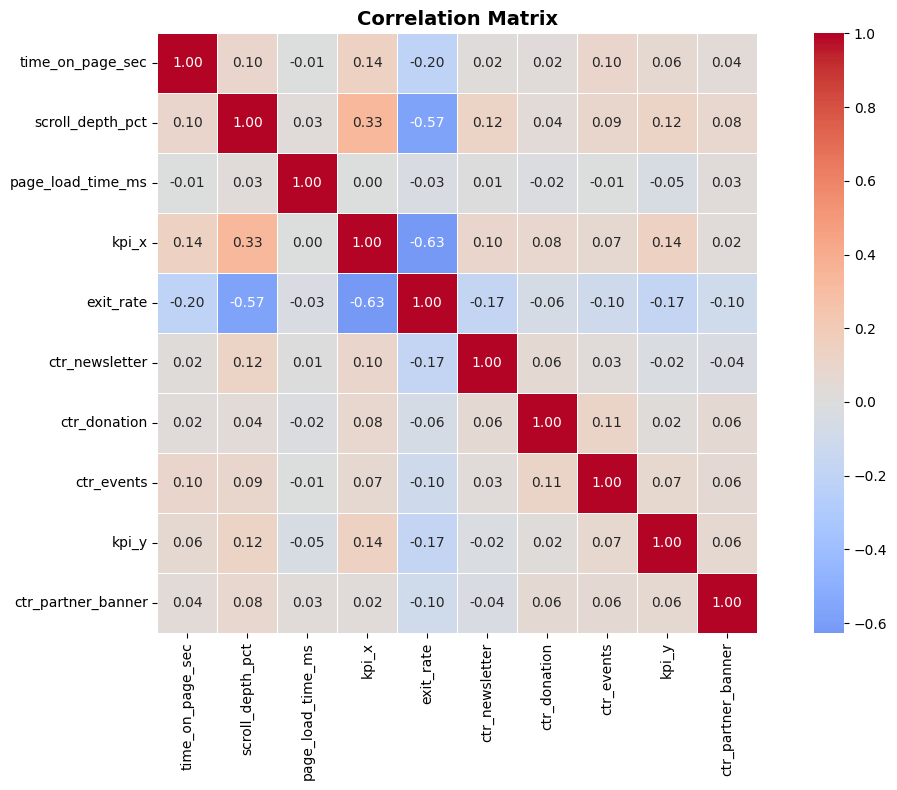

In [30]:
numeric_cols = ['time_on_page_sec', 'scroll_depth_pct', 'page_load_time_ms', 
                'kpi_x', 'exit_rate', 'ctr_newsletter', 'ctr_donation', 
                'ctr_events', 'kpi_y', 'ctr_partner_banner']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150)
plt.show()

### Key Observations

- **kpi_x & exit_rate (-0.63)** — strongest relationship: visitors with higher kpi_x 
  scores are much less likely to exit, suggesting kpi_x measures engagement
- **scroll_depth_pct & exit_rate (-0.57)** — visitors who scroll more are less likely 
  to exit, which makes intuitive sense
- **kpi_x & scroll_depth_pct (0.33)** — moderate positive correlation, both capture 
  engagement behavior
- **page_load_time_ms** — near zero correlation with everything, confirming load time 
  is independent of user behavior
- **CTR metrics** — very low correlations with each other, clicks on one element 
  don't predict clicks on another

## EDA Summary

### Dataset Overview
- **1,163 visitors** across two arms, no missing values
- **Pre (control):** 349 visitors | **Treatment:** 814 visitors
- Test ran simultaneously from **Feb 22 to Mar 6, 2026**

### Data Quality
- No missing values across all 16 columns
- `arrival_time` and `exit_time` had mixed timestamp precision — handled with `format='mixed'`
- `time_on_page_sec` and `page_load_time_ms` had ~11% outliers each )

### Key Findings
- Almost all binary metrics were **lower in the treatment arm**, suggesting the new CTA button did not improve performance
- **exit_rate increased** from 23.2% to 33.4% in the treatment arm — more visitors left after seeing the new button
- **scroll_depth_pct was higher in the pre/control arm**, suggesting more engaged browsing before the change
- **kpi_y dropped** from 8.9% to 5.4% in the treatment arm

### Correlation Insights
- `kpi_x` and `exit_rate` are strongly negatively correlated (-0.63) — kpi_x captures engagement
- `scroll_depth_pct` and `exit_rate` are negatively correlated (-0.57)

In [ ]:
# Export cleaned dataset for downstream analysis (e.g., power calculations)
clean_path = '../data/TXB_23_landingpage_clean.csv'

df.to_csv(clean_path, index=False)
print(f"Saved cleaned dataset to: {clean_path}")

Saved cleaned dataset to: ../data/TXB_23_landingpage_clean.csv
